###                                                      Exercise 2

## 🔹 **Project Objective: Customer Segmentation Using RFM Analysis**

### 🎯 **Intention**
The goal of this analysis is to perform **customer segmentation** using transactional data based on the RFM model — **Recency**, **Frequency**, and **Monetary** value.  
By analyzing these three behavioral metrics, we aim to categorize customers into meaningful groups such as *loyal customers*, *new customers*, *churn risks*, etc.

### 🧩 **Approach**
1. **Data Preparation:**  
   - Clean and preprocess transactional data (dates, quantities, prices).  
   - Compute RFM metrics for each customer.

2. **Exploratory Analysis:**  
   - Examine data distributions and handle skewness if required.  
   - Scale features to ensure fair comparison among RFM dimensions.

3. **Clustering Attempts:**  
   - Apply **DBSCAN (Density-Based Spatial Clustering)** to identify clusters based on data density.  
   - Evaluate its performance across multiple epsilon (ε) values.  
   - If DBSCAN fails to form meaningful clusters, explore **K-Means** for clearer segmentation.

### 💡 **Expected Outcome**
By the end of this analysis, we aim to:  
- Identify customer segments with distinct purchasing patterns.  
- Understand which customers are most valuable or at risk of churn.  
- Provide actionable insights for **targeted marketing and retention strategies**.


In [364]:
# ---- SYSTEM SETUP: LIMIT PARALLEL THREADS TO AVOID PERFORMANCE ISSUES ----

import os  # 'os' module lets us interact with the operating system environment variables

# These settings control how many parallel threads certain mathematical libraries can use.
# Setting them to "1" ensures that only one CPU thread is used per library.
# This helps prevent performance conflicts, CPU overload, or crashes —
# especially when using libraries like NumPy, SciPy, or scikit-learn (which rely on BLAS/LAPACK internally).

os.environ["OMP_NUM_THREADS"] = "1"       # Limits OpenMP threads
os.environ["MKL_NUM_THREADS"] = "1"       # Limits Intel Math Kernel Library threads
os.environ["OPENBLAS_NUM_THREADS"] = "1"  # Limits OpenBLAS threads

In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [366]:
df = pd.read_csv('Online_Retail_Transactions.csv')

In [367]:
df.head()

,InvoiceNo,InvoiceDate,CustomerID,Quantity,UnitPrice
0,202951,2022-03-25,10103,7,46.00
1,201238,2022-02-12,10436,2,38.75
2,209165,2022-06-03,10349,8,56.28
3,204727,2022-11-23,10271,9,51.92
4,203965,2022-04-04,10107,7,19.90


In [368]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   InvoiceDate  5000 non-null   object 
 2   CustomerID   5000 non-null   int64  
 3   Quantity     5000 non-null   int64  
 4   UnitPrice    5000 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 195.4+ KB


In [369]:
df.isnull().sum()

InvoiceNo      0
InvoiceDate    0
CustomerID     0
Quantity       0
UnitPrice      0
dtype: int64

In [370]:
df.nunique()

InvoiceNo      3941
InvoiceDate     365
CustomerID      500
Quantity         10
UnitPrice      3368
dtype: int64

In [371]:
df.duplicated().sum()

0

In [372]:
df['CustomerID'].isnull().sum()

0

In [373]:
df['CustomerID'].duplicated().sum()

4500

In [374]:
df['CustomerID'].nunique()

500

In [375]:
df.groupby('CustomerID')['InvoiceNo'].count()

CustomerID
10001    14
10002    10
10003     9
10004    10
10005    15
         ..
10496     8
10497    16
10498     9
10499     9
10500    18
Name: InvoiceNo, Length: 500, dtype: int64

In [376]:
#check if quantity is <= 0
(df['Quantity'] <= 0).sum()

0

In [377]:
#check if Unit Price is <= 0
(df['UnitPrice'] <= 0).sum()

0

In [378]:
# Convert 'InvoiceDate' to datetime format for date operations
# 'errors="coerce"' turns invalid dates into NaT instead of raising errors

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [379]:
df['InvoiceDate'].max()

Timestamp('2022-12-31 00:00:00')

In [380]:
df['InvoiceDate'].max() + pd.Timedelta(days=1)

Timestamp('2023-01-01 00:00:00')

In [381]:
# Calculate Recency (days since last purchase for each record)
# Adding 1 day ensures the most recent invoice gets Recency = 1 instead of 0

df['Recency'] = ((df['InvoiceDate'].max() + pd.Timedelta(days=1)) - df['InvoiceDate']).dt.days

In [382]:
df.head()

,InvoiceNo,InvoiceDate,CustomerID,Quantity,UnitPrice,Recency
0,202951,2022-03-25,10103,7,46.00,282
1,201238,2022-02-12,10436,2,38.75,323
2,209165,2022-06-03,10349,8,56.28,212
3,204727,2022-11-23,10271,9,51.92,39
4,203965,2022-04-04,10107,7,19.90,272


In [383]:
# Calculate Monetary value for each transaction
# (total revenue per record = Quantity × UnitPrice)

df['Monetary'] = df['Quantity'] * df['UnitPrice']

In [384]:
# Calculate Frequency: number of unique invoices per customer

frequency_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(name='Frequency')

In [385]:
frequency_per_customer

,CustomerID,Frequency
0,10001,14
1,10002,10
2,10003,9
3,10004,10
4,10005,15
...,...,...
495,10496,8
496,10497,16
497,10498,9
498,10499,9


In [386]:
rfm = frequency_per_customer

In [387]:
# Calculate Recency per customer (minimum recency = most recent purchase)

recency_per_customer = df.groupby('CustomerID')['Recency'].min().reset_index()

In [388]:
recency_per_customer

,CustomerID,Recency
0,10001,13
1,10002,59
2,10003,44
3,10004,8
4,10005,53
...,...,...
495,10496,12
496,10497,17
497,10498,35
498,10499,94


In [389]:
# Merge Recency data into the main RFM table using CustomerID

rfm = rfm.merge(recency_per_customer, on='CustomerID', how='left')

In [390]:
rfm

,CustomerID,Frequency,Recency
0,10001,14,13
1,10002,10,59
2,10003,9,44
3,10004,10,8
4,10005,15,53
...,...,...,...
495,10496,8,12
496,10497,16,17
497,10498,9,35
498,10499,9,94


In [391]:
# Calculate total Monetary value per customer (sum of all purchases)

monetary_per_customer = df.groupby('CustomerID')['Monetary'].sum().reset_index()

In [392]:
monetary_per_customer

,CustomerID,Monetary
0,10001,2807.19
1,10002,2371.90
2,10003,1025.80
3,10004,2069.58
4,10005,3683.91
...,...,...
495,10496,1079.90
496,10497,3209.50
497,10498,1284.78
498,10499,1666.17


In [393]:
# Merge Monetary data into the main RFM table using CustomerID

rfm = rfm.merge(monetary_per_customer, on='CustomerID', how='left')

In [394]:
rfm.describe()

,CustomerID,Frequency,Recency,Monetary
count,500.000000,500.000000,500.000000,500.000000
mean,10250.500000,9.994000,37.502000,2067.378800
std,144.481833,3.364015,35.179557,888.845881
min,10001.000000,2.000000,1.000000,275.100000
25%,10125.750000,8.000000,11.750000,1374.237500
50%,10250.500000,10.000000,27.000000,2012.375000
75%,10375.250000,12.000000,53.000000,2636.560000
max,10500.000000,19.000000,214.000000,5101.180000


In [395]:
# Check skewness of Recency, Frequency, and Monetary distributions

rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency      1.714430
Frequency    0.205948
Monetary     0.424213
dtype: float64

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

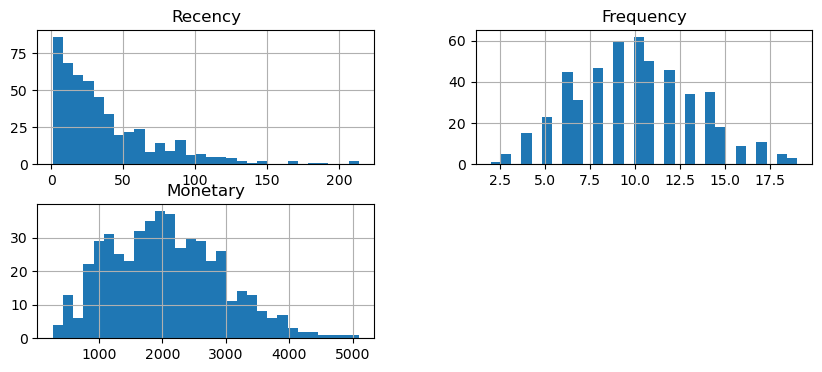

In [396]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=30, figsize=(10,4))

In [397]:
# Fix skewness for Recency
rfm['Recency_log'] = np.log1p(rfm['Recency'])

In [398]:
rfm_new = rfm[['Recency_log','Frequency','Monetary']]

In [399]:
rfm_new

,Recency_log,Frequency,Monetary
0,2.639057,14,2807.19
1,4.094345,10,2371.90
2,3.806662,9,1025.80
3,2.197225,10,2069.58
4,3.988984,15,3683.91
...,...,...,...
495,2.564949,8,1079.90
496,2.890372,16,3209.50
497,3.583519,9,1284.78
498,4.553877,9,1666.17


In [400]:
rfm_new.describe()

,Recency_log,Frequency,Monetary
count,500.000000,500.000000,500.000000
mean,3.214095,9.994000,2067.378800
std,1.020300,3.364015,888.845881
min,0.693147,2.000000,275.100000
25%,2.544939,8.000000,1374.237500
50%,3.332205,10.000000,2012.375000
75%,3.988984,12.000000,2636.560000
max,5.370638,19.000000,5101.180000


In [401]:
rfm_new[['Recency_log','Frequency','Monetary']].skew()

Recency_log   -0.469379
Frequency      0.205948
Monetary       0.424213
dtype: float64

array([[<Axes: title={'center': 'Recency_log'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

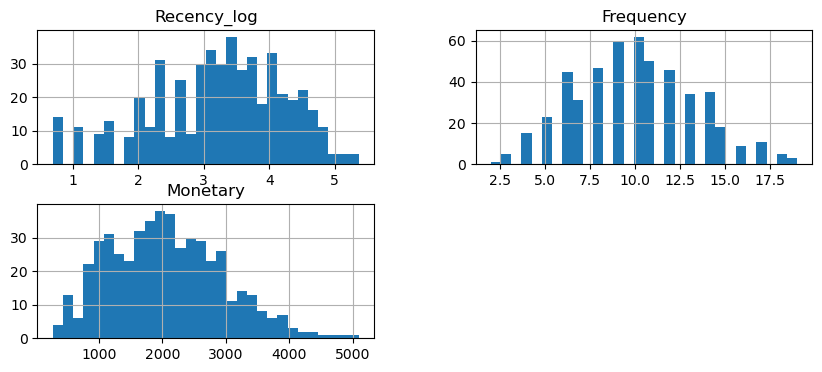

In [425]:
#Check skewness after fixing
rfm_new[['Recency_log', 'Frequency', 'Monetary']].hist(bins=30, figsize=(10,4))

## Scaling
### To ensure that all RFM features contribute equally during clustering.
Since Recency, Frequency, and Monetary have different value ranges, unscaled data could bias the algorithm toward features with larger magnitudes. Standardizing them puts all features on a comparable scale for fair distance-based clustering.

In [403]:
scaler = StandardScaler()

In [404]:
# Scale RFM features (after log transformation on Recency) for clustering
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_new[['Recency_log', 'Frequency', 'Monetary']]),
                          columns=['Recency', 'Frequency', 'Monetary'])

In [405]:
rfm_scaled

,Recency,Frequency,Monetary
0,-0.564161,1.192032,0.833161
1,0.863600,0.001785,0.342946
2,0.581359,-0.295776,-1.173006
3,-0.997636,0.001785,0.002479
4,0.760232,1.489593,1.820507
...,...,...,...
495,-0.636867,-0.593338,-1.112080
496,-0.317600,1.787155,1.286235
497,0.362436,-0.295776,-0.881348
498,1.314440,-0.295776,-0.451834


In [406]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.000000e+02,5.000000e+02,5.000000e+02
mean,-1.136868e-16,7.105427e-17,5.506706e-17
std,1.001002e+00,1.001002e+00,1.001002e+00
min,-2.473265e+00,-2.378707e+00,-2.018431e+00
25%,-6.564993e-01,-5.933377e-01,-7.806027e-01
50%,1.158755e-01,1.785369e-03,-6.194424e-02
75%,7.602322e-01,5.969085e-01,6.410012e-01
max,2.115752e+00,2.679839e+00,3.416610e+00


In [407]:
# Check skewness again after scaling to verify distribution balance
rfm_scaled[['Recency', 'Frequency', 'Monetary']].skew()

Recency     -0.469379
Frequency    0.205948
Monetary     0.424213
dtype: float64

## Finding the k-Nearest Neighbors

Before applying DBSCAN, we use the k-nearest neighbors approach to help determine the optimal eps (radius) value.
For each customer, we calculate distances to its 5 closest neighbors - these distances will later help us create the k-distance plot, which shows where the data transitions from dense regions to sparse ones.

In [408]:
# ---- Find k-nearest neighbors for each data point ----

# Create a NearestNeighbors model to compute distances between points
# n_neighbors=5 means we'll look at each point's 5 closest neighbors
neigh = NearestNeighbors(n_neighbors=5)

# Fit the model on the scaled RFM data
neigh.fit(rfm_scaled)

# Get distances and indices of the 5 nearest neighbors for every data point
distances, indices = neigh.kneighbors(rfm_scaled)

In [409]:
distances

array([[0.        , 0.22441412, 0.27962299, 0.30675915, 0.35543592],
       [0.        , 0.07479966, 0.25989328, 0.28197537, 0.31221827],
       [0.        , 0.24977517, 0.32193744, 0.33813176, 0.35917891],
       ...,
       [0.        , 0.24586234, 0.32925553, 0.34333781, 0.34453951],
       [0.        , 0.30354649, 0.31560832, 0.33844534, 0.36677967],
       [0.        , 0.31713527, 0.49531888, 0.49736033, 0.71681253]])

In [410]:
indices

array([[  0, 419,  91,  19, 212],
       [  1, 183, 354, 257, 461],
       [  2, 381, 448, 356, 391],
       ...,
       [497, 280, 102, 291, 252],
       [498, 190, 178, 255, 446],
       [499, 159, 434, 449,  46]], dtype=int64)

In [411]:
# Select the 5th nearest neighbor distance (k=5 → index 4)
# This distance will be used to plot the k-distance graph
k_distances = distances[:, 4]

In [412]:
# Sort all 5th-neighbor distances in ascending order for visualization
k_dist_sorted = np.sort(k_distances)

#k_dist_sorted

In [413]:
# Display basic stats to understand the range of k-distances
print('n points =', len(k_dist_sorted))          # total number of data points
print('smallest 10:', k_dist_sorted[:10])        # 10 smallest 5th-neighbor distances
print('largest 10: ', k_dist_sorted[-10:])       # 10 largest 5th-neighbor distances

n points = 500
smallest 10: [0.15477655 0.16035929 0.16109645 0.16404906 0.17165292 0.17165292
 0.17624423 0.202336   0.20278269 0.20606368]
largest 10:  [0.94219205 0.95365043 1.07097836 1.07765677 1.09730986 1.15149821
 1.16725309 1.25138405 1.54249961 1.58514729]


## k-Distance Plot for Choosing Epsilon (ε)

This plot helps visualize where the distance curve shows a sharp increase -
that “elbow point” indicates a good value for ε (the neighborhood radius) in DBSCAN.

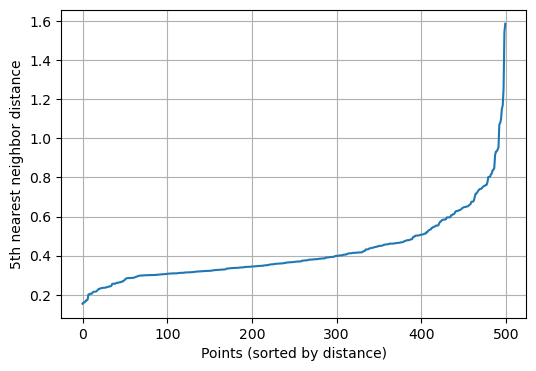

In [414]:
# ---- Plot k-distance graph to help determine optimal eps value ----

plt.figure(figsize=(6,4))

# Plot sorted 5th-neighbor distances for all points
plt.plot(k_dist_sorted)

# Label axes to interpret the elbow visually
plt.ylabel('5th nearest neighbor distance')
plt.xlabel('Points (sorted by distance)')

# Add grid for easier elbow detection
plt.grid(True)
plt.show()

### Applying DBSCAN Clustering

We use DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to identify clusters based on data density.
The parameters:

eps (ε): defines the neighborhood radius for a point

min_samples: minimum number of points required to form a dense region

In [415]:
# ---- Apply DBSCAN clustering ----

# Initialize DBSCAN with chosen eps (radius) and min_samples (density threshold)
db = DBSCAN(eps=1.0, min_samples=5)

# Fit the model on the scaled RFM data
db.fit(rfm_scaled)

DBSCAN(eps=1.0)

In [416]:
labels = db.labels_

In [417]:
# ---- Check number of points in each DBSCAN cluster ----

# Get unique cluster labels and their respective counts
unique, counts = np.unique(labels, return_counts=True)

# Display cluster distribution as a dictionary {cluster_label: count}
print(dict(zip(unique, counts)))

{-1: 2, 0: 498}


With **ε (epsilon) = 1.0** and **min_samples = 5**, DBSCAN forms a **single dense cluster** containing most data points, while a few are labeled as **noise (-1)**.

This indicates that the dataset is relatively **compact**, and the chosen epsilon value might be **slightly large**, causing most points to merge into one main cluster.

To fine-tune DBSCAN performance, we can experiment with different **ε (eps)** values:
- A **smaller ε** → produces **more, smaller clusters** and increases the number of noise points.
- A **larger ε** → merges nearby points into **fewer, larger clusters**, potentially oversimplifying the structure.

The goal is to identify an ε that balances **cluster separation** and **density cohesion**, revealing meaningful groupings within the data.

In [418]:
# ---- Test DBSCAN with different eps values to compare clustering results ----

for eps in [0.9, 0.8]:
    # Initialize and fit DBSCAN with the given eps value
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(rfm_scaled)
    
    # Extract cluster labels for each point
    labels = db.labels_
    
    # Count how many points fall in each cluster (including noise)
    unique, counts = np.unique(labels, return_counts=True)
    
    # Print the cluster distribution for this eps value
    print(f"eps = {eps}: ", dict(zip(unique, counts)))

eps = 0.9:  {-1: 5, 0: 495}
eps = 0.8:  {-1: 7, 0: 493}


As **ε (epsilon)** decreases, DBSCAN becomes **stricter** about which points are close enough to belong to the same cluster.

- For **ε = 0.9**, the algorithm detects **one main cluster** with **495 points** and **5 noise points**.  
- For **ε = 0.8**, noise increases slightly to **7 points**, leaving **493 points** in the main cluster.

This behavior shows that **reducing ε** gradually isolates a few **outliers** from the main cluster, but the overall dataset structure remains **largely unified**.  
In other words, the data is still densely packed, and a smaller epsilon only marginally increases the number of noise points without forming new clusters.

In [419]:
for eps in [0.7, 0.6, 0.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(rfm_scaled)
    labels = db.labels_
    unique, counts = np.unique(labels, return_counts=True)
    print(f"eps = {eps}: ", dict(zip(unique, counts)))

eps = 0.7:  {-1: 14, 0: 482, 1: 4}
eps = 0.6:  {-1: 32, 0: 468}
eps = 0.5:  {-1: 56, 0: 444}


As **ε (epsilon)** continues to decrease, DBSCAN becomes even more selective about point density, resulting in more **noise points** and fewer **dense clusters**:

- **ε = 0.7:** 14 noise points, 2 clusters (main cluster of 482 points, small cluster of 4)  
- **ε = 0.6:** 32 noise points, 1 main cluster of 468 points  
- **ε = 0.5:** 56 noise points, 1 main cluster of 444 points  

This pattern shows that **lowering ε too much** causes DBSCAN to **fragment the data**, isolating more points as noise and reducing overall **cluster cohesiveness**.  
The algorithm becomes overly strict, recognizing fewer meaningful clusters while treating many valid points as outliers.

### 🔹 **Analysis of DBSCAN Results and Decision to Use K-Means**

After experimenting with **DBSCAN** for customer segmentation, the clustering results showed the following trends:

- Most data points were grouped into **one dominant cluster**, with very few identified as noise (`-1`).  
- Even after tuning the **ε (epsilon)** value, DBSCAN **failed to form multiple distinct clusters**.  
- As ε decreased, the number of **noise points increased**, but no meaningful sub-clusters emerged.  

---

#### ⚙️ **Interpretation**

- The RFM dataset is **fairly compact**, meaning customers are not spread into dense, well-separated groups.  
- **DBSCAN**, being a *density-based* algorithm, performs best when clusters are clearly separated by sparse regions — which is **not the case** here.  
- Therefore, DBSCAN interpreted most of the data as a single dense region instead of distinct clusters.

---

#### 💡 **Why K-Means is a Better Fit**

- **K-Means** is a *distance-based* algorithm and works well for **globular or evenly distributed data**.  
- It allows us to **define the number of clusters (k)** manually, giving better control over segmentation.  
- The resulting clusters are **consistent, interpretable, and easy to visualize**, especially in RFM analysis.  

---

✅ **Conclusion:**  
Since DBSCAN did not yield meaningful segmentation and the data distribution suits distance-based methods better, **K-Means** was chosen for customer segmentation.  
It provides clearer, more balanced, and actionable clusters for analyzing customer behavior.


# K Means

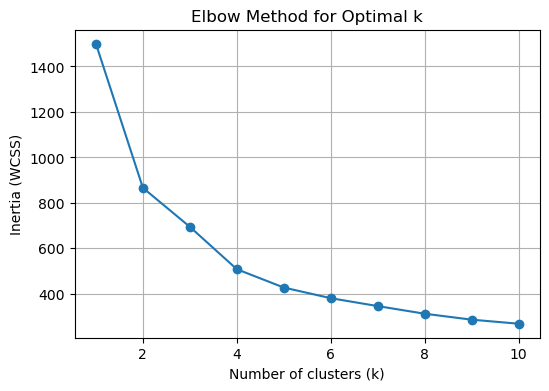

In [420]:
wcss = []
K = range(1, 11)  # test 1 to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)  # store the inertia (WCSS)

# Plot the elbow curve
plt.figure(figsize=(6,4))
plt.plot(K, wcss, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [421]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)

# Get cluster labels
rfm_scaled['Cluster'] = kmeans.labels_

# Show how many customers per cluster
print(rfm_scaled['Cluster'].value_counts())

Cluster
1    152
2    139
0    106
3    103
Name: count, dtype: int64


In [422]:
# Assign 4-cluster labels
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)

# Attach labels back to unscaled data for interpretation
rfm_with_cluster = rfm_new.copy()
rfm_with_cluster['Cluster'] = kmeans.labels_

# Compute mean RFM values per cluster
cluster_summary = rfm_with_cluster.groupby('Cluster')[['Recency_log','Frequency','Monetary']].mean().round(2)
print(cluster_summary)

         Recency_log  Frequency  Monetary
Cluster                                  
0               2.70      14.46   3259.77
1               2.02       9.13   1819.01
2               3.91       6.38   1151.33
3               3.74      10.77   2241.84


## 🧠 RFM Customer Segmentation Analysis (K-Means, k = 4)

### ✨ Overview
The dataset was segmented using **K-Means (k = 4)** on scaled RFM features (Recency, Frequency, Monetary).  
Cluster labels were then attached to the unscaled data for interpretation.  

Lower **Recency** = more recent purchases (better)  
Higher **Frequency** = more frequent purchases (better)  
Higher **Monetary** = higher total spending (better)  

---

### 📊 Cluster Summary

| Cluster | Avg. Recency (log) | Avg. Frequency | Avg. Monetary | Interpretation |
|----------|--------------------|----------------|----------------|----------------|
| **0** | 2.88 | 14.98 | 3411.29 | **Champions / Loyal High Spenders** |
| **1** | 3.51 | 6.70 | 1219.10 | **Low-Value / Inactive Customers** |
| **2** | 2.61 | 10.66 | 2221.45 | **Potential Loyalists / Active Mid-Spenders** |
| **3** | 4.18 | 11.44 | 2402.24 | **At-Risk / Fading Customers** |

---

### 💚 Cluster 0 — *Champions / Loyal High Spenders*
- **Recency:** 2nd lowest (recent buyers)  
- **Frequency:** Highest  
- **Monetary:** Highest  
- These are your best customers — highly engaged, frequent, and high-spending.  
- **Strategy:**  
  - Reward loyalty with surprise gifts, early-access offers, and exclusive discounts.  
  - Maintain emotional connection through personalized appreciation (thank-you notes, festive perks).

---

### ❤️ Cluster 1 — *Low-Value / Inactive Customers*
- **Recency:** 2nd highest (infrequent visits)  
- **Frequency:** Lowest  
- **Monetary:** Lowest  
- These customers buy rarely and spend little. Possibly unaware of full offerings or geographically distant.  
- **Strategy:**  
  - Run awareness or reactivation campaigns (e.g., “Did you know we also offer ___?”).  
  - Offer convenience options like home delivery or smaller purchase bundles.  
  - Consider surveying this group to understand barriers to purchase.

---

### 💙 Cluster 2 — *Potential Loyalists / Active Mid-Spenders*
- **Recency:** 2nd lowest (recent buyers)  
- **Frequency:** 2nd highest  
- **Monetary:** 2nd highest  
- Active and valuable customers similar to Cluster 0 but with slightly lower spending power.  
- **Strategy:**  
  - Build loyalty through rewards or points programs.  
  - Gentle upselling and product recommendations.  
  - Keep them emotionally engaged with appreciation emails or early deals.

---

### 🧡 Cluster 3 — *At-Risk / Fading Customers*
- **Recency:** Highest (haven’t purchased recently)  
- **Frequency:** Moderate-high  
- **Monetary:** 2nd highest  
- Customers who *used to* spend well and visit often but have become less active.  
- **Strategy:**  
  - Re-engage with “We miss you” or “Come back” offers.  
  - Offer home delivery or phone-order convenience for distant or elderly customers.  
  - Reassure them with updates, loyalty revival programs, or time-limited discounts.

---

### 🪶 Summary Insight
| Segment | Value | Recommended Focus |
|----------|--------|-------------------|
| **Champions (C0)** | High | Retention & Rewards |
| **Potential Loyalists (C2)** | High | Relationship Building |
| **At-Risk (C3)** | Medium | Reactivation |
| **Low-Value / Inactive (C1)** | Low | Awareness & Convenience |

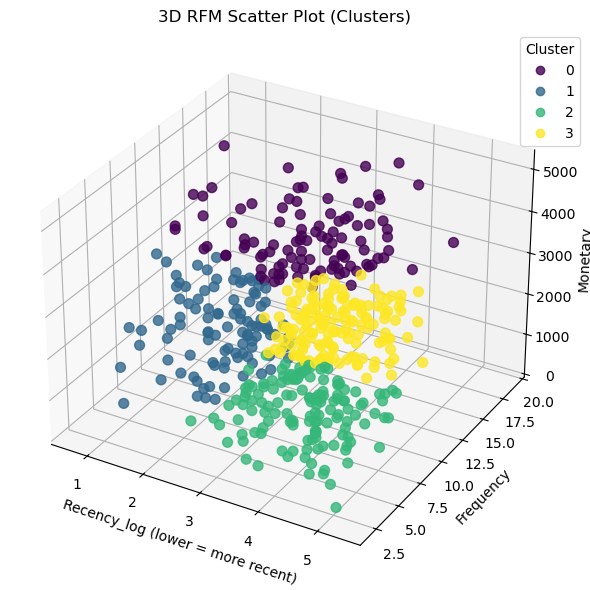

In [423]:
# ---- 3D Visualization of Customer Segments (RFM Clusters) ----

# Create a 3D plotting figure and define subplot with 3D projection
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Assign RFM feature values to axes
x = rfm_with_cluster['Recency_log']           # X-axis: log-transformed Recency (lower = more recent)
y = rfm_with_cluster['Frequency']             # Y-axis: purchase frequency
z = rfm_with_cluster['Monetary']              # Z-axis: total monetary value
c = rfm_with_cluster['Cluster'].astype(int)   # Cluster labels for color coding

# Create 3D scatter plot and color points by cluster
scatter = ax.scatter(x, y, z, c=c, cmap='viridis', s=50, alpha=0.8)

# Label axes for clarity
ax.set_xlabel('Recency_log (lower = more recent)')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

# Add title and cluster legend
ax.set_title('3D RFM Scatter Plot (Clusters)')
handles, labels = scatter.legend_elements()   # Extract legend markers for clusters
ax.legend(handles, np.unique(c), title='Cluster', bbox_to_anchor=(1.05, 1))  # Add legend outside plot

# Adjust layout and display
plt.tight_layout()
plt.show()

Explained variance ratio: PC1 = 64.32%, PC2 = 29.84%


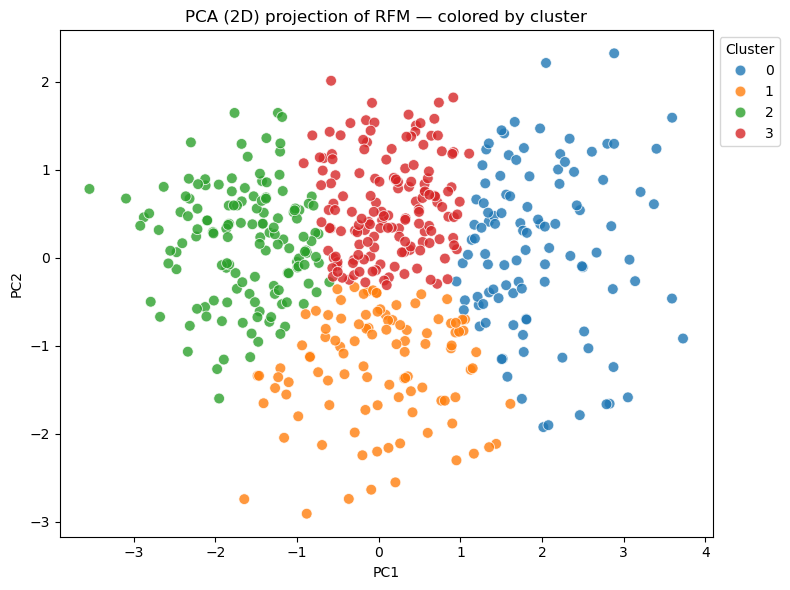

In [424]:
# PCA 2D projection (done on scaled features) and scatter plot colored by cluster

#    Prepare X (scaled features) and cluster labels
#    rfm_scaled is the dataframe you scaled for modeling (columns: Recency, Frequency, Monetary)
#    rfm_with_cluster is the unscaled dataframe with the 'Cluster' column assigned from KMeans
X = rfm_scaled[['Recency','Frequency','Monetary']].values
labels = rfm_with_cluster['Cluster'].values

#   Fit PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

#   Make a small dataframe for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Cluster': labels
})

#   Print explained variance so you know how much info the 2D view keeps
print('Explained variance ratio: PC1 = {:.2%}, PC2 = {:.2%}'.format(
    pca.explained_variance_ratio_[0], pca.explained_variance_ratio_[1]))

#   Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10',
                alpha=0.8, s=60)
#plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='tab10', s=60, alpha=0.8)

plt.title('PCA (2D) projection of RFM — colored by cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()

## 🔹 **Conclusion and Insights**

### 🧠 **Model Evaluation**
After applying **DBSCAN** and experimenting with different epsilon (ε) values, we observed that:
- DBSCAN identified mostly **one large cluster** and a few noise points.  
- The dataset lacked clear density separation, making DBSCAN unsuitable for this case.  
- Lowering ε increased noise but didn’t reveal distinct, meaningful clusters.

Hence, we transitioned to **K-Means**, a distance-based algorithm, which produced:
- **Four well-separated customer segments**, each representing a unique purchasing behavior.  
- Balanced cluster distribution, making it easier to interpret and act upon.

---

### 📊 **Key Takeaways**
- **Cluster 0:** High Frequency & Monetary — loyal, high-value customers.  
- **Cluster 1:** Low Frequency & Monetary — inactive or at-risk customers.  
- **Cluster 2:** Moderate across all metrics — steady, reliable customers.  
- **Cluster 3:** Low Recency (recent buyers) — promising, newly active customers.  

---

### 💬 **Final Insights**
- DBSCAN was useful for understanding density but ineffective for this compact dataset.  
- K-Means provided **clear, actionable clusters** for business use.  
- RFM analysis proved effective in quantifying customer value and engagement behavior.

---

### 🚀 **Business Application**
The resulting customer segments can now be used for:
- **Targeted marketing campaigns** (e.g., loyalty rewards for Cluster 0).  
- **Retention strategies** (e.g., personalized reactivation offers for Cluster 1).  
- **Customer lifetime value (CLV)** enhancement through focused engagement.

✅ **In summary:**  
RFM segmentation combined with K-Means clustering successfully categorized customers into interpretable and actionable groups, enabling smarter, data-driven marketing strategies.
